# Module 8: Interest Rate Derivatives Pricing

This notebook explores the pricing of standard interest rate derivatives (Swaps, Caps, Floors, and Swaptions) using both the Vasicek short-rate model (analytic) and Black's 1976 Model (market standard).

In [1]:
import sys

sys.path.append("/Users/mukundankit/Documents/Finance/bond_modelling")
import numpy as np
import matplotlib.pyplot as plt

from src.curve.nelson_siegel import NelsonSiegelCurve
from src.models.stochastic import VasicekModel
from src.derivatives.swap import InterestRateSwap, swap_rate, swap_pv
from src.derivatives.cap_floor import Cap, Floor, cap_floor_pv, cap_floor_black
from src.derivatives.swaption import (
    Swaption,
    price_swaption_jamshidian,
    price_swaption_black,
)
from src.utils.plotting import set_theme

set_theme()

## 1. Interest Rate Swap (IRS) & Par Curve
First, we calibrate a Nelson-Siegel curve and compute the Par Swap Curve across multiple tenors. The Par Swap Curve shows the fixed rate required for a newly initiated swap to have exactly 0 present value.

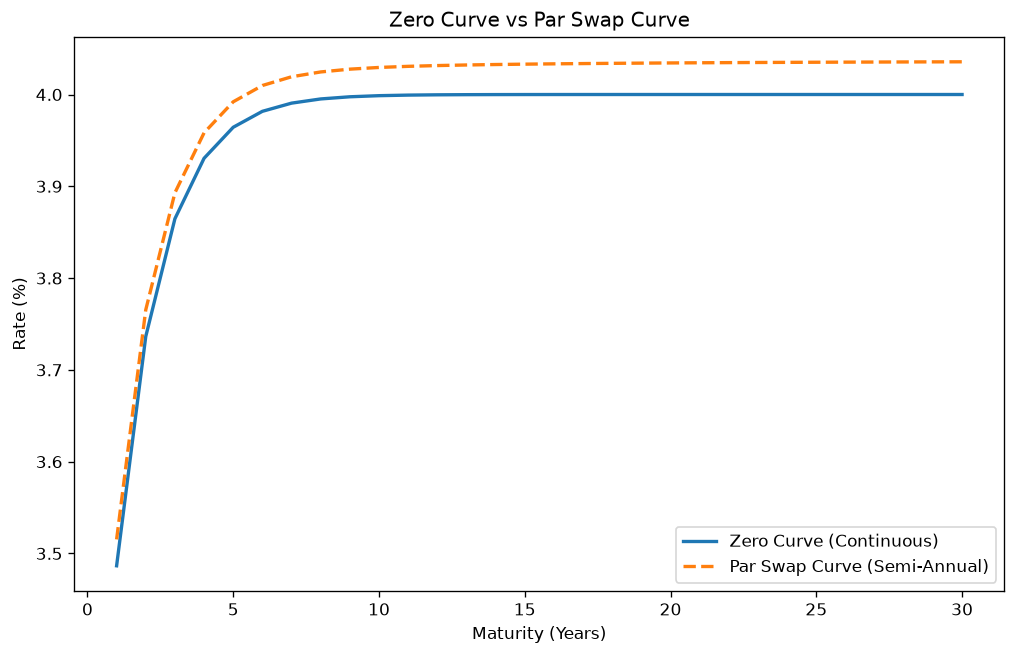

In [2]:
curve = NelsonSiegelCurve(beta0=0.04, beta1=-0.01, beta2=0.01, tau=1.5)

tenors = np.linspace(1, 30, 30)
par_rates = []
zero_rates = []

for T in tenors:
    swap = InterestRateSwap(notional=10_000_000, fixed_rate=0.0, tenor=T, freq=2)
    par_rates.append(swap_rate(swap, curve))
    zero_rates.append(curve(T))

plt.figure(figsize=(10, 6))
plt.plot(
    tenors, np.array(zero_rates) * 100, label="Zero Curve (Continuous)", linewidth=2
)
plt.plot(
    tenors,
    np.array(par_rates) * 100,
    label="Par Swap Curve (Semi-Annual)",
    linestyle="--",
    linewidth=2,
)
plt.xlabel("Maturity (Years)")
plt.ylabel("Rate (%)")
plt.title("Zero Curve vs Par Swap Curve")
plt.legend()
plt.show()

## 2. Interest Rate Caps and Floors
We price caps and floors across a range of strikes. This demonstrates the non-linear optionality inherent in these instruments.

We will use a flat continuous zero curve to isolate the effect of strikes and price them using both Vasicek and Black's Model.

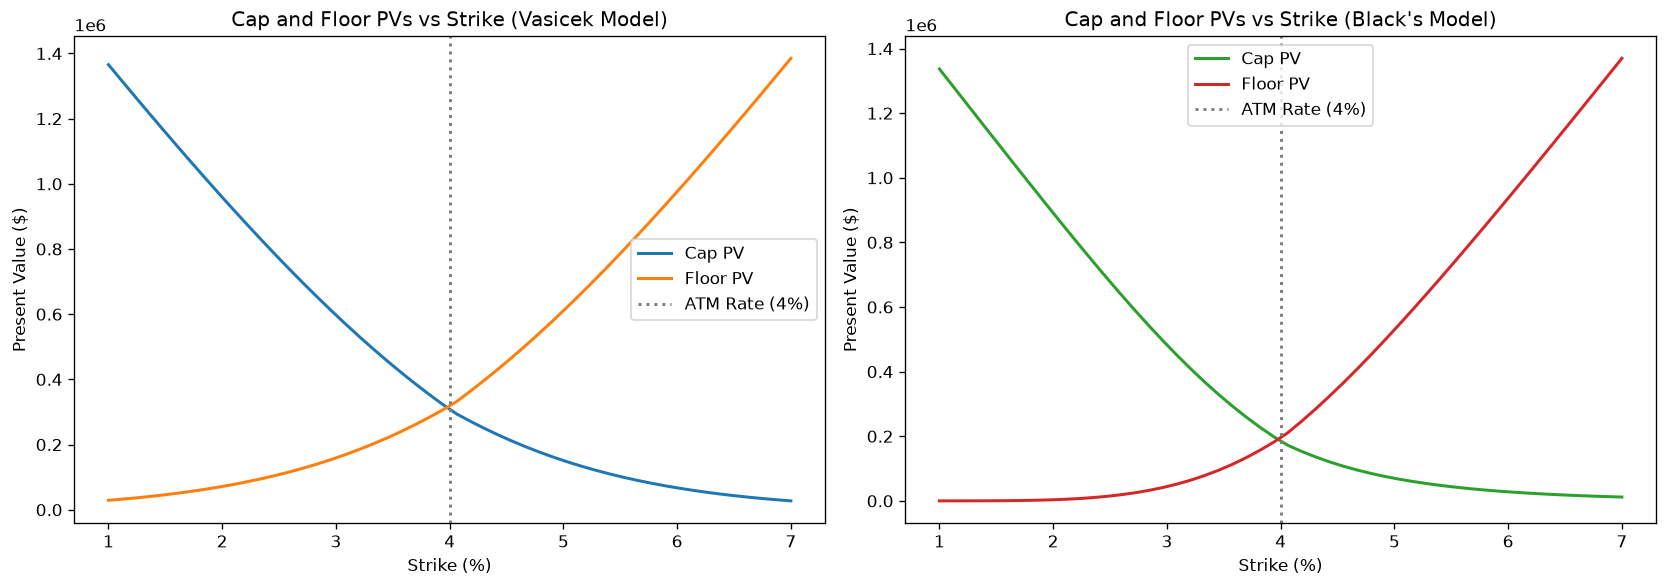

In [3]:
model = VasicekModel(a=0.1, b=0.04, sigma=0.015)
r_t = 0.04


def zcb_curve(t):
    if t == 0:
        return r_t
    return -float(np.log(model.zcb_price(r_t, t))) / t


strikes = np.linspace(0.01, 0.07, 50)
vol = 0.20  # 20% lognormal volatility

pv_caps_v, pv_floors_v = [], []
pv_caps_b, pv_floors_b = [], []

for K in strikes:
    cap = Cap(notional=10_000_000, strike=K, tenor=5, freq=2)
    floor = Floor(notional=10_000_000, strike=K, tenor=5, freq=2)

    # Vasicek Prices
    pv_caps_v.append(cap_floor_pv(cap, model, r_t))
    pv_floors_v.append(cap_floor_pv(floor, model, r_t))

    # Black Prices
    pv_caps_b.append(cap_floor_black(cap, zcb_curve, vol))
    pv_floors_b.append(cap_floor_black(floor, zcb_curve, vol))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Vasicek Prices
ax1.plot(strikes * 100, pv_caps_v, label="Cap PV")
ax1.plot(strikes * 100, pv_floors_v, label="Floor PV")
ax1.axvline(r_t * 100, color="grey", linestyle=":", label="ATM Rate (4%)")
ax1.set_title("Cap and Floor PVs vs Strike (Vasicek Model)")
ax1.set_xlabel("Strike (%)")
ax1.set_ylabel("Present Value ($)")
ax1.legend()

# Plot 2: Black Model Prices
ax2.plot(strikes * 100, pv_caps_b, label="Cap PV", color="C2")
ax2.plot(strikes * 100, pv_floors_b, label="Floor PV", color="C3")
ax2.axvline(r_t * 100, color="grey", linestyle=":", label="ATM Rate (4%)")
ax2.set_title("Cap and Floor PVs vs Strike (Black's Model)")
ax2.set_xlabel("Strike (%)")
ax2.set_ylabel("Present Value ($)")
ax2.legend()

plt.tight_layout()
plt.show()

### Cap-Floor Parity Validation
By Put-Call parity, `Cap - Floor = Forward Payer Swap`. We will verify this relationship computationally.

In [4]:
# Verify parity at K=0.04
strike = 0.04
cap = Cap(notional=10_000_000, strike=strike, tenor=5, freq=2)
floor = Floor(notional=10_000_000, strike=strike, tenor=5, freq=2)
swap_cf = InterestRateSwap(notional=10_000_000, fixed_rate=strike, tenor=5, freq=2)

v_cap = cap_floor_pv(cap, model, r_t)
v_floor = cap_floor_pv(floor, model, r_t)
v_swap = swap_pv(swap_cf, zcb_curve, position="payer")

print(f"Parity Difference (Vasicek): ${(v_cap - v_floor) - v_swap:,.6f}")

b_cap = cap_floor_black(cap, zcb_curve, vol)
b_floor = cap_floor_black(floor, zcb_curve, vol)
print(f"Parity Difference (Black):   ${(b_cap - b_floor) - v_swap:,.6f}")

Parity Difference (Vasicek): $-0.000000
Parity Difference (Black):   $0.000000


## 3. European Swaptions & Volatility Sensitivity
A Swaption gives the holder the right to enter an IRS at a future date. 
We price a 2y5y (2 year expiry, 5 year underlying tenor) Swaption and analyze its sensitivity to Implied Volatility under Black's model.

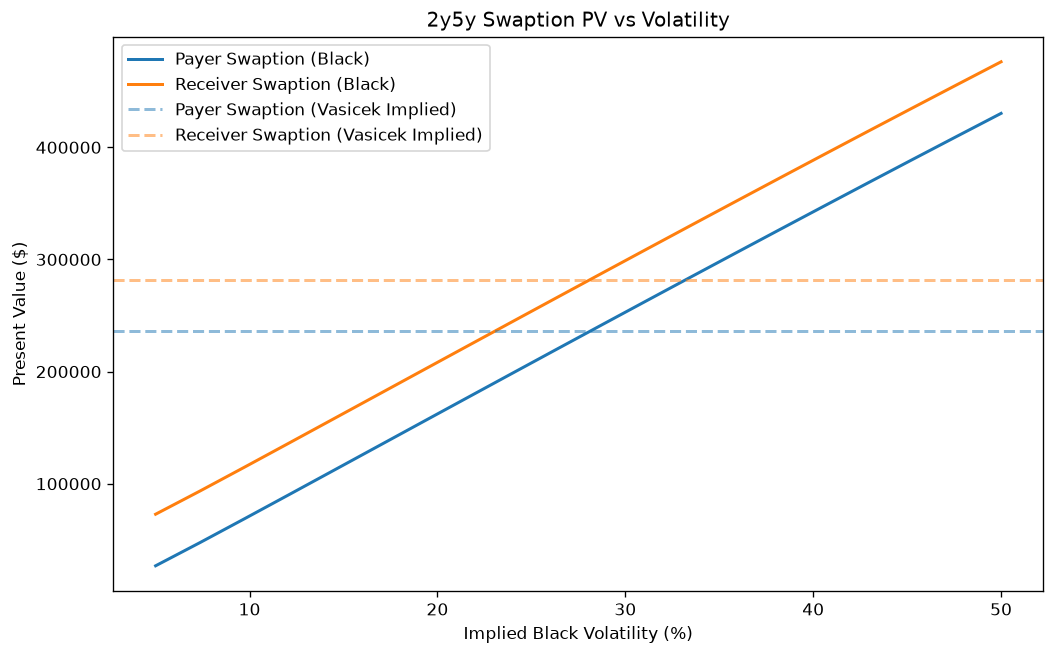

In [5]:
swap_underlying = InterestRateSwap(
    notional=10_000_000, fixed_rate=0.04, tenor=7, freq=2
)
payer_swaption = Swaption(swap=swap_underlying, expiry=2.0, option_type="payer")
receiver_swaption = Swaption(swap=swap_underlying, expiry=2.0, option_type="receiver")

vols = np.linspace(0.05, 0.50, 20)
pv_payer_sw, pv_receiver_sw = [], []

for v in vols:
    pv_payer_sw.append(price_swaption_black(payer_swaption, zcb_curve, v))
    pv_receiver_sw.append(price_swaption_black(receiver_swaption, zcb_curve, v))

plt.figure(figsize=(10, 6))
plt.plot(vols * 100, pv_payer_sw, label="Payer Swaption (Black)")
plt.plot(vols * 100, pv_receiver_sw, label="Receiver Swaption (Black)")

# Add Vasicek Baseline (Independent of Black Vol)
v_payer = price_swaption_jamshidian(payer_swaption, model, r_t)
v_recv = price_swaption_jamshidian(receiver_swaption, model, r_t)
plt.axhline(
    v_payer,
    color="C0",
    linestyle="--",
    label="Payer Swaption (Vasicek Implied)",
    alpha=0.5,
)
plt.axhline(
    v_recv,
    color="C1",
    linestyle="--",
    label="Receiver Swaption (Vasicek Implied)",
    alpha=0.5,
)

plt.xlabel("Implied Black Volatility (%)")
plt.ylabel("Present Value ($)")
plt.title("2y5y Swaption PV vs Volatility")
plt.legend()
plt.show()